## 🧩 步驟 0：匯入套件

In [25]:
import os
import torch
import torchvision
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix
)

#### 確認有沒有使用到GPU

In [26]:
# GPU check
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

Using device: cuda
GPU name: NVIDIA GeForce RTX 3050 Laptop GPU


## 🧩 步驟 1：匯入資料

In [27]:
DATA_DIR = "archive/AMDNet23 Dataset"

train_dir = os.path.join(DATA_DIR, "train")
valid_dir = os.path.join(DATA_DIR, "valid")

## 🧩 步驟 2：基礎資料處理
（Transform + DataLoader）

* 為什麼要這樣處理（報告合理性）

* Resize(調整大小)：CNN 需要固定輸入大小「配合模型輸入規格」

* Normalize(正規化)：符合 ImageNet 預訓練模型分布

* Augmentation(增強)：減少 overfitting（醫學影像資料量有限）「增加資料多樣性」

In [28]:
# Train transform (含 augmentation)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

# Validation transform（不做增強）
valid_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])


In [29]:
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
valid_dataset = datasets.ImageFolder(valid_dir, transform=valid_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)

class_names = train_dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)


Classes: ['amd', 'cataract', 'diabetes', 'normal']


## 🧩 步驟 3：資料分析（EDA）

#### 📊 (1) 類別分布分析

In [30]:
def count_images(dataset):
    labels = [label for _, label in dataset.samples]
    return pd.Series(labels).value_counts().sort_index()

train_counts = count_images(train_dataset)
valid_counts = count_images(valid_dataset)

df_dist = pd.DataFrame({
    "Train": train_counts,
    "Valid": valid_counts
})
df_dist.index = class_names
df_dist

,Train,Valid
amd,394,100
cataract,400,100
diabetes,400,100
normal,400,100


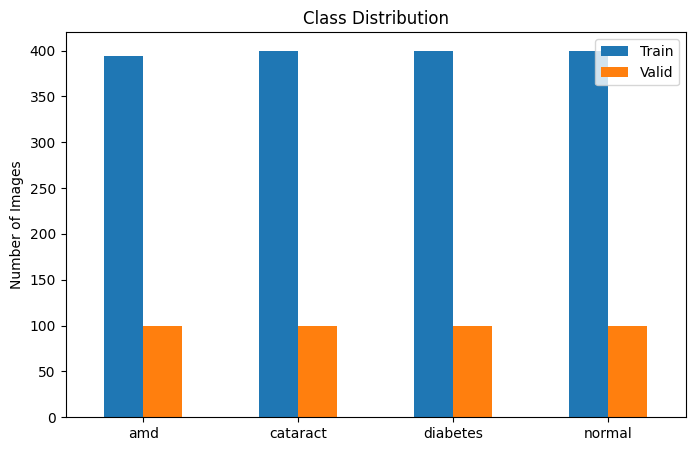

In [31]:
df_dist.plot(kind="bar", figsize=(8,5))
plt.title("Class Distribution")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.show()

##### 📌 報告可寫：
從類別分布可觀察到資料存在輕微不平衡現象，因此後續實驗採用多種評估指標（Precision、Recall、F1-score）以避免僅以 Accuracy 判斷模型效能

#### 📊(2) 顯示樣本影像（確認資料正確）

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0050609].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0291154].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0291154].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0130792].


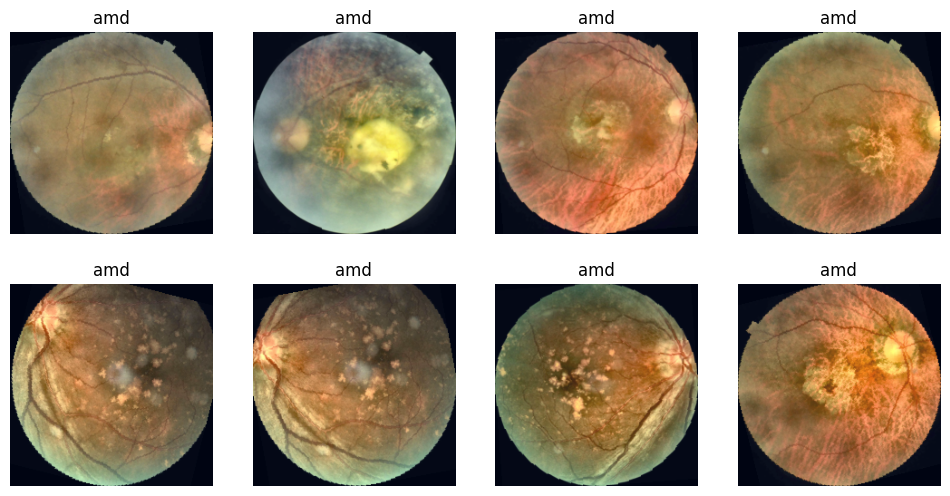

In [32]:
def show_images(dataset, n=8):
    plt.figure(figsize=(12,6))
    for i in range(n):
        img, label = dataset[i]
        img = img.permute(1,2,0)
        img = img * 0.229 + 0.485  # inverse normalize (approx)
        plt.subplot(2,4,i+1)
        plt.imshow(img)
        plt.title(class_names[label])
        plt.axis("off")
    plt.show()

show_images(train_dataset)


## 🧩 步驟 4：建立模型
（ResNet18 作為 CNN 實驗）

In [33]:
def build_model(num_classes):
    model = models.resnet18(pretrained=True)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

## 🧩 步驟 5：訓練與評估函式（通用）

In [34]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    return running_loss / len(loader)


In [35]:
def evaluate(model, loader):
    model.eval()
    y_true, y_pred = [], []
    running_loss = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            loss = criterion(outputs, y)
            running_loss += loss.item()

            preds = torch.argmax(outputs, 1)
            y_true.extend(y.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    return {
        "loss": running_loss / len(loader),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average="macro"),
        "recall": recall_score(y_true, y_pred, average="macro"),
        "f1": f1_score(y_true, y_pred, average="macro"),
        "cm": confusion_matrix(y_true, y_pred)
    }


## 🧩 步驟 6：做實驗
（可重複呼叫 → 多組實驗）

In [36]:
model = build_model(num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

EPOCHS = 10
history = []

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer)
    val_metrics = evaluate(model, valid_loader)

    val_metrics["train_loss"] = train_loss
    history.append(val_metrics)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Acc: {val_metrics['accuracy']:.4f}")


c:\Users\USER\anaconda3\envs\torch2\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\USER\anaconda3\envs\torch2\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
11.8%

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\USER/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100.0%


Epoch 1/10 | Train Loss: 0.4916 | Val Acc: 0.9125
Epoch 2/10 | Train Loss: 0.2350 | Val Acc: 0.8975
Epoch 3/10 | Train Loss: 0.1706 | Val Acc: 0.9225
Epoch 4/10 | Train Loss: 0.1271 | Val Acc: 0.9500
Epoch 5/10 | Train Loss: 0.0899 | Val Acc: 0.9275
Epoch 6/10 | Train Loss: 0.0690 | Val Acc: 0.9500
Epoch 7/10 | Train Loss: 0.0452 | Val Acc: 0.9375
Epoch 8/10 | Train Loss: 0.0373 | Val Acc: 0.9600
Epoch 9/10 | Train Loss: 0.0473 | Val Acc: 0.9600
Epoch 10/10 | Train Loss: 0.0438 | Val Acc: 0.9000


## 🧩 步驟 7：繪圖（Loss / Accuracy）

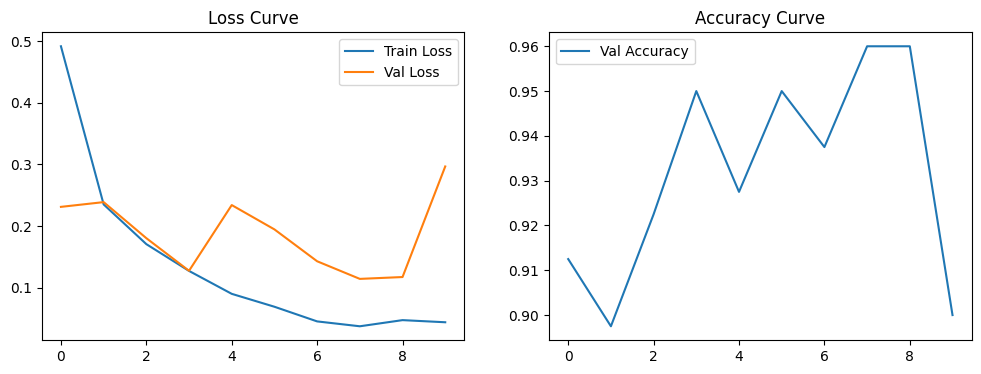

In [37]:
df_hist = pd.DataFrame(history)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(df_hist["train_loss"], label="Train Loss")
plt.plot(df_hist["loss"], label="Val Loss")
plt.legend()
plt.title("Loss Curve")

plt.subplot(1,2,2)
plt.plot(df_hist["accuracy"], label="Val Accuracy")
plt.legend()
plt.title("Accuracy Curve")
plt.show()


## 🧩 步驟 8：Confusion Matrix

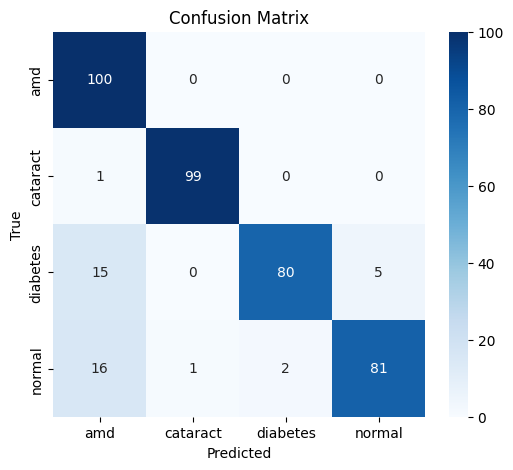

In [38]:
cm = history[-1]["cm"]

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


## 🧩 步驟 9：匯出每個實驗結果表格

In [39]:
results_df = df_hist[["accuracy", "precision", "recall", "f1", "loss"]]
results_df["epoch"] = range(1, len(results_df)+1)

results_df.to_csv("experiment_results.csv", index=False)
results_df

C:\Users\USER\AppData\Local\Temp\ipykernel_32108\2263417294.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results_df["epoch"] = range(1, len(results_df)+1)


,accuracy,precision,recall,f1,loss,epoch
0,0.9125,0.912418,0.9125,0.911793,0.231031,1
1,0.8975,0.901499,0.8975,0.897494,0.238734,2
2,0.9225,0.929359,0.9225,0.920162,0.180242,3
3,0.9500,0.951133,0.9500,0.949618,0.127303,4
4,0.9275,0.941327,0.9275,0.927709,0.233936,5
5,0.9500,0.955207,0.9500,0.948914,0.194464,6
6,0.9375,0.941360,0.9375,0.938253,0.142760,7
7,0.9600,0.960683,0.9600,0.959446,0.114177,8
8,0.9600,0.960760,0.9600,0.959848,0.117178,9
9,0.9000,0.916261,0.9000,0.900539,0.296588,10


##### 📌 你現在已經具備：

* PyTorch CNN 實作

* GPU 訓練

* 合理 EDA

* 多指標評估

* 圖表 + CSV 匯出